<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [1]:
import pandas as pd
import psycopg2
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 

In [3]:
DBNAME = 'project_sql'
USER = 'skillfactory'
PASSWORD = 'cCkxxLVrDE8EbvjueeMedPKt'
HOST = '84.201.134.129'
PORT = 5432

connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [22]:
query_3_1 = f'''
Select count(id) from vacancies
'''

In [23]:
result = pd.read_sql_query(query_3_1, connection)

print(f"Количество вакансий: {result}")

Количество вакансий:    count
0  49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [24]:
# текст запроса
query = f'''
Select count(id) from employers
'''

In [25]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(f"Количество вакансий: {result}")

Количество вакансий:    count
0  23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [26]:
# текст запроса
query = f'''
Select count(id) from areas
'''

In [27]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(f"Количество регионов: {result}")

Количество регионов:    count
0   1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [28]:
# текст запроса
query = f'''
Select count(id) from industries
'''

In [29]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(f"Количество сфер деятельности: {result}")

Количество сфер деятельности:    count
0    294


***

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [30]:
# текст запроса
query = '''
SELECT 
    a.name AS area, 
    COUNT(v.id) AS cnt
FROM 
    vacancies v
JOIN 
    areas a ON v.area_id = a.id
GROUP BY 
    a.name
ORDER BY 
    cnt DESC
'''

In [31]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

                area   cnt
0             Москва  5333
1    Санкт-Петербург  2851
2              Минск  2112
3        Новосибирск  2006
4             Алматы  1892
..               ...   ...
764       Тарко-Сале     1
765    Новоаннинский     1
766            Бирск     1
767           Сасово     1
768             Анна     1

[769 rows x 2 columns]


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [32]:
# текст запроса
query = '''
SELECT 
    COUNT(id) AS cnt
FROM 
    vacancies
WHERE 
    salary_from IS NOT NULL OR salary_to IS NOT NULL
'''

In [33]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

     cnt
0  24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [34]:
# текст запроса
query = '''
SELECT 
    ROUND(AVG(salary_from)) AS avg_salary_from,
    ROUND(AVG(salary_to)) AS avg_salary_to
FROM 
    vacancies
WHERE 
    salary_from IS NOT NULL OR salary_to IS NOT NULL
'''

In [35]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   avg_salary_from  avg_salary_to
0          71065.0       110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [36]:
# текст запроса
query = '''
SELECT 
    schedule,
    employment,
    COUNT(id) AS cnt
FROM 
    vacancies
GROUP BY 
    schedule, employment
ORDER BY 
    cnt DESC
'''

In [37]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

            schedule           employment    cnt
0        Полный день     Полная занятость  35367
1   Удаленная работа     Полная занятость   7802
2      Гибкий график     Полная занятость   1593
3   Удаленная работа  Частичная занятость   1312
4     Сменный график     Полная занятость    940
5        Полный день           Стажировка    569
6     Вахтовый метод     Полная занятость    367
7        Полный день  Частичная занятость    347
8      Гибкий график  Частичная занятость    312
9        Полный день     Проектная работа    141
10  Удаленная работа     Проектная работа    133
11     Гибкий график           Стажировка    116
12    Сменный график  Частичная занятость    101
13  Удаленная работа           Стажировка     64
14     Гибкий график     Проектная работа     18
15    Сменный график           Стажировка     12
16    Вахтовый метод     Проектная работа      2
17    Сменный график     Проектная работа      1


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [38]:
# текст запроса
query = '''
SELECT 
    experience,
    COUNT(id) AS cnt
FROM 
    vacancies
GROUP BY 
    experience
ORDER BY 
    cnt ASC
'''

In [39]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

           experience    cnt
0         Более 6 лет   1337
1           Нет опыта   7197
2       От 3 до 6 лет  14511
3  От 1 года до 3 лет  26152


***

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [40]:
# текст запроса
query = '''
WITH ranked_employers AS (
    SELECT 
        e.name AS employer_name,
        COUNT(v.id) AS vacancy_count,
        RANK() OVER (ORDER BY COUNT(v.id) DESC) AS rank
    FROM 
        vacancies v
    JOIN 
        employers e ON v.employer_id = e.id
    GROUP BY 
        e.name
)
SELECT 
    employer_name,
    vacancy_count
FROM 
    ranked_employers
WHERE 
    rank IN (1, 5)
ORDER BY 
    rank
'''

In [41]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   employer_name  vacancy_count
0         Яндекс           1933
1  Газпром нефть            331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [85]:
# текст запроса
query1 = '''
SELECT 
    a.id AS area_id,
    a.name AS area_name,
    COUNT(DISTINCT e.id) AS employer_count,
    COUNT(v.id) AS vacancy_count
FROM areas a
LEFT JOIN employers e ON e.area = a.id
LEFT JOIN vacancies v ON v.area_id = a.id
GROUP BY a.id, a.name

'''
query2 = '''
WITH region_stats AS (
    SELECT 
        a.id AS area_id,
        a.name AS area_name,
        COUNT(DISTINCT e.id) AS employer_count,
        COUNT(v.id) AS vacancy_count
    FROM areas a
    LEFT JOIN employers e ON e.area = a.id
    LEFT JOIN vacancies v ON v.area_id = a.id
    GROUP BY a.id, a.name
)
SELECT 
    area_name,
    employer_count,
    vacancy_count
FROM region_stats
ORDER BY vacancy_count ASC, employer_count DESC
LIMIT 1
'''

In [86]:
# результат запроса
result = pd.read_sql_query(query1, connection)

print(result)

result = pd.read_sql_query(query2, connection)

print(result)

      area_id                      area_name  employer_count  vacancy_count
0           1                         Москва            5864       31272712
1           2                Санкт-Петербург            2217        6320667
2           3                   Екатеринбург             609        1034082
3           4                    Новосибирск             573        1149438
4           6                      Австралия               6              0
...       ...                            ...             ...            ...
1357     6669                       Песчаное               0              0
1358     6759                    Усть-Абакан               0              0
1359     6765  Белый Яр (Республика Хакасия)               0              0
1360     6773    Андреевка (Хасанский район)               0              0
1361     6923                  Верхневилюйск               0              0

[1362 rows x 4 columns]
  area_name  employer_count  vacancy_count
0    Россия         

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [44]:
# текст запроса
query = '''
SELECT 
    e.id AS employer_id,
    e.name AS employer_name,
    COUNT(DISTINCT v.area_id) AS region_count
FROM employers e
LEFT JOIN vacancies v ON v.employer_id = e.id
GROUP BY e.id, e.name
ORDER BY region_count DESC
'''

In [45]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

       employer_id           employer_name  region_count
0             1740                  Яндекс           181
1             2748              Ростелеком           152
2          5724811              Спецремонт           116
3          5130287  Поляков Денис Иванович            88
4          3682876               ООО ЕФИН             71
...            ...                     ...           ...
23496      5287515              Но Смокинг             0
23497      2839354        МАСТЕРСКАЯ CREED             0
23498      5774578           Dzing Finance             0
23499      5775069                    КОРС             0
23500           15             Наука-Связь             0

[23501 rows x 3 columns]


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [54]:
# текст запроса
query = '''
SELECT 
    COUNT(*) AS employers_without_industry
FROM employers e
WHERE e.id NOT IN (
    SELECT DISTINCT ei.employer_id
    FROM employers_industries ei
)
'''

In [55]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   employers_without_industry
0                        8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [52]:
# текст запроса
query = '''
WITH employers_with_four_industries AS (
    SELECT 
        e.id,
        e.name
    FROM employers e
    JOIN employers_industries ei ON ei.employer_id = e.id
    GROUP BY e.id, e.name
    HAVING COUNT(ei.industry_id) = 4
),
ranked AS (
    SELECT 
        name,
        ROW_NUMBER() OVER (ORDER BY name ASC) AS rn
    FROM employers_with_four_industries
)
SELECT name
FROM ranked
WHERE rn = 3
'''

In [53]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   name
0  2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [56]:
# текст запроса
query = '''
SELECT 
    COUNT(DISTINCT ei.employer_id) AS employer_count
FROM employers_industries ei
JOIN industries i ON i.id = ei.industry_id
WHERE i.name = 'Разработка программного обеспечения'
'''

In [57]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   employer_count
0            3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [81]:
import pandas as pd
from io import StringIO

html_content = response.text
tables = pd.read_html(StringIO(html_content), header=0)
table = tables[0]

table['Город'] = "'"+table['Город']+"'"
cities = table['Город'].to_list()
cities = ', '.join(cities)
print(cities)

'Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград'


In [84]:
# текст запроса
query = f'''
WITH yandex_vacancies AS (
    SELECT 
        v.area_id,
        a.name AS area_name,
        COUNT(*) AS vacancy_count
    FROM vacancies v
    JOIN employers e ON e.id = v.employer_id
    JOIN areas a ON a.id = v.area_id
    WHERE e.name = 'Яндекс'
      AND a.name IN (
          {cities}
      )
    GROUP BY v.area_id, a.name
),
total_vacancies AS (
    SELECT 
        'Total' AS area_name,
        SUM(vacancy_count) AS vacancy_count
    FROM yandex_vacancies
)
SELECT 
    area_name,
    vacancy_count
FROM yandex_vacancies

UNION ALL

SELECT 
    area_name,
    vacancy_count
FROM total_vacancies
ORDER BY area_name
'''

In [83]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

          area_name  vacancy_count
0             Total          485.0
1         Волгоград           24.0
2           Воронеж           32.0
3      Екатеринбург           39.0
4            Казань           25.0
5         Краснодар           30.0
6        Красноярск           23.0
7            Москва           54.0
8   Нижний Новгород           36.0
9       Новосибирск           35.0
10             Омск           21.0
11            Пермь           25.0
12   Ростов-на-Дону           25.0
13           Самара           26.0
14  Санкт-Петербург           42.0
15              Уфа           26.0
16        Челябинск           22.0


***

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [87]:
# текст запроса
query = f'''
SELECT 
    COUNT(*) AS data_related_vacancies
FROM vacancies
WHERE LOWER(name) LIKE '%data%' OR LOWER(name) LIKE '%данн%'
'''

In [88]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   data_related_vacancies
0                    1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [91]:
# текст запроса
query = f'''
SELECT 
    COUNT(*) AS junior_data_scientist_vacancies
FROM vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%' OR
    LOWER(name) LIKE '%data science%' OR
    LOWER(name) LIKE '%исследователь данных%' OR
    (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%') OR
    LOWER(name) LIKE '%machine learning%' OR
    LOWER(name) LIKE '%машинн%обучен%'
)
AND (
    LOWER(name) LIKE '%junior%' OR
    experience = 'Нет опыта' OR
    schedule = 'Стажировка' -- Заменяем employment_type на schedule
)
'''

In [92]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   junior_data_scientist_vacancies
0                               51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [93]:
# текст запроса
query = f'''
SELECT 
    COUNT(*) AS ds_sql_vacancies
FROM vacancies
WHERE (
    LOWER(name) LIKE '%data scientist%' OR
    LOWER(name) LIKE '%data science%' OR
    LOWER(name) LIKE '%исследователь данных%' OR
    (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%') OR
    LOWER(name) LIKE '%machine learning%' OR
    LOWER(name) LIKE '%машинн%обучен%'
)
AND (
    LOWER(key_skills) LIKE '%sql%' OR
    LOWER(key_skills) LIKE '%postgres%'
)
'''

In [94]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   ds_sql_vacancies
0               229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [166]:
# текст запроса
query = f'''
WITH ds_vacancies AS (
    SELECT *
    FROM vacancies
    WHERE (
    LOWER(name) LIKE '%data scientist%' OR
    LOWER(name) LIKE '%data science%' OR
    LOWER(name) LIKE '%исследователь данных%' OR
    (LOWER(name) LIKE '%ml%' AND LOWER(name) NOT LIKE '%html%') OR
    LOWER(name) LIKE '%machine learning%' OR
    LOWER(name) LIKE '%машинн%обучен%'
)
), skill_counts AS (
    SELECT 
        LENGTH(key_skills) - LENGTH(REPLACE(key_skills, CHR(9), '')) + 1 AS skill_count
    FROM ds_vacancies
    WHERE key_skills IS NOT NULL
)
SELECT ROUND(AVG(skill_count)::NUMERIC, 2) AS avg_key_skills
FROM skill_counts
'''

In [167]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result)

   python_ds_vacancies
0                  357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [12]:
# текст запроса
query = f'''
(
    SELECT 
        ROUND(AVG(LENGTH(key_skills) - LENGTH(REPLACE(key_skills, '\t', '')) + 1), 2) AS AVG_kl_navikov
    FROM vacancies v
    WHERE
        (name ILIKE '%data scientist%' OR
         name ILIKE '%data science%' OR
         name ILIKE '%исследователь данных%' OR
         name ILIKE '%machine learning%' OR
         name ILIKE '%машинн%обучен%' OR
         (name LIKE '%ML%' AND name NOT ILIKE '%HTML%')
        )
        AND key_skills IS NOT NULL
)
'''

In [13]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result.head())

   avg_kl_navikov
0            6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [14]:
# текст запроса
query = '''
WITH ds_vacancies AS (
    SELECT 
        experience,
        COALESCE((salary_from + salary_to) / 2, salary_from, salary_to) AS avg_salary
    FROM vacancies
    WHERE 
        (name ILIKE '%data scientist%' OR
         name ILIKE '%data science%' OR
         name ILIKE '%исследователь данных%' OR
         name ILIKE '%machine learning%' OR
         name ILIKE '%машинн%обучен%' OR
         (name LIKE '%ML%' AND name NOT ILIKE '%HTML%'))
        AND (salary_from IS NOT NULL OR salary_to IS NOT NULL)
),
experience_salary AS (
    SELECT 
        experience,
        ROUND(AVG(avg_salary)) AS avg_salary_by_experience
    FROM ds_vacancies
    GROUP BY experience
)
SELECT 
    avg_salary_by_experience
FROM experience_salary
WHERE experience = 'От 3 до 6 лет';'''

In [15]:
# результат запроса
result = pd.read_sql_query(query, connection)

print(result.head())

   avg_salary_by_experience
0                  243115.0


***

# Общий вывод по проекту

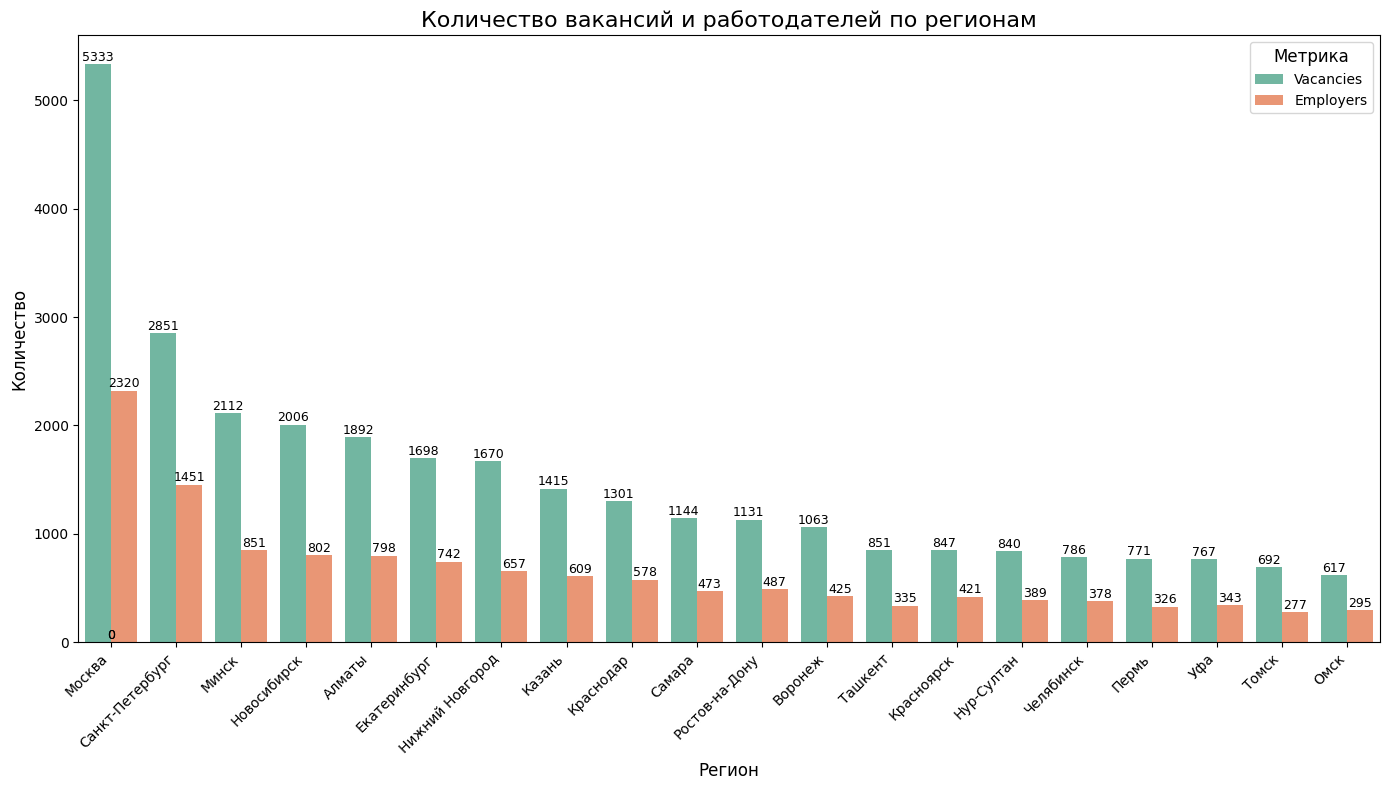

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных о топ-регионах по количеству вакансий
top_vacancies = pd.read_sql_query(
    '''
    SELECT a.name AS region, COUNT(*) AS vacancy_count
    FROM areas a
    JOIN vacancies v ON a.id = v.area_id
    GROUP BY a.name
    ORDER BY vacancy_count DESC
    LIMIT 20
    ''',
    connection
)

# Загрузка данных о топ-регионах по количеству работодателей
top_employers = pd.read_sql_query(
    '''
    SELECT a.name AS region, COUNT(DISTINCT e.id) AS employer_count
    FROM areas a
    JOIN vacancies v ON a.id = v.area_id
    JOIN employers e ON v.employer_id = e.id
    GROUP BY a.name
    ORDER BY employer_count DESC
    LIMIT 20
    ''',
    connection
)

merged_data = pd.merge(top_vacancies, top_employers, on='region', how='outer').fillna(0)
merged_data = merged_data.sort_values('vacancy_count', ascending=False)

# Подготовка данных для графика
plot_data = pd.DataFrame({
    'Region': merged_data['region'],
    'Vacancies': merged_data['vacancy_count'],
    'Employers': merged_data['employer_count']
})

# Преобразование данных для удобства визуализации
melted_data = plot_data.melt(id_vars='Region', 
                              value_vars=['Vacancies', 'Employers'], 
                              var_name='Metric', 
                              value_name='Count')

# Построение графика
plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(data=melted_data, x='Region', y='Count', hue='Metric', ci=None, dodge=True, palette='Set2')

# Настройка внешнего вида графика
plt.title('Количество вакансий и работодателей по регионам', fontsize=16)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Метрика', fontsize=10, title_fontsize=12)

# Числовые метки на столбцы
for patch in bar_plot.patches:
    height = patch.get_height()
    bar_plot.annotate(f'{int(height)}', 
                       (patch.get_x() + patch.get_width() / 2., height), 
                       ha='center', va='center', 
                       xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

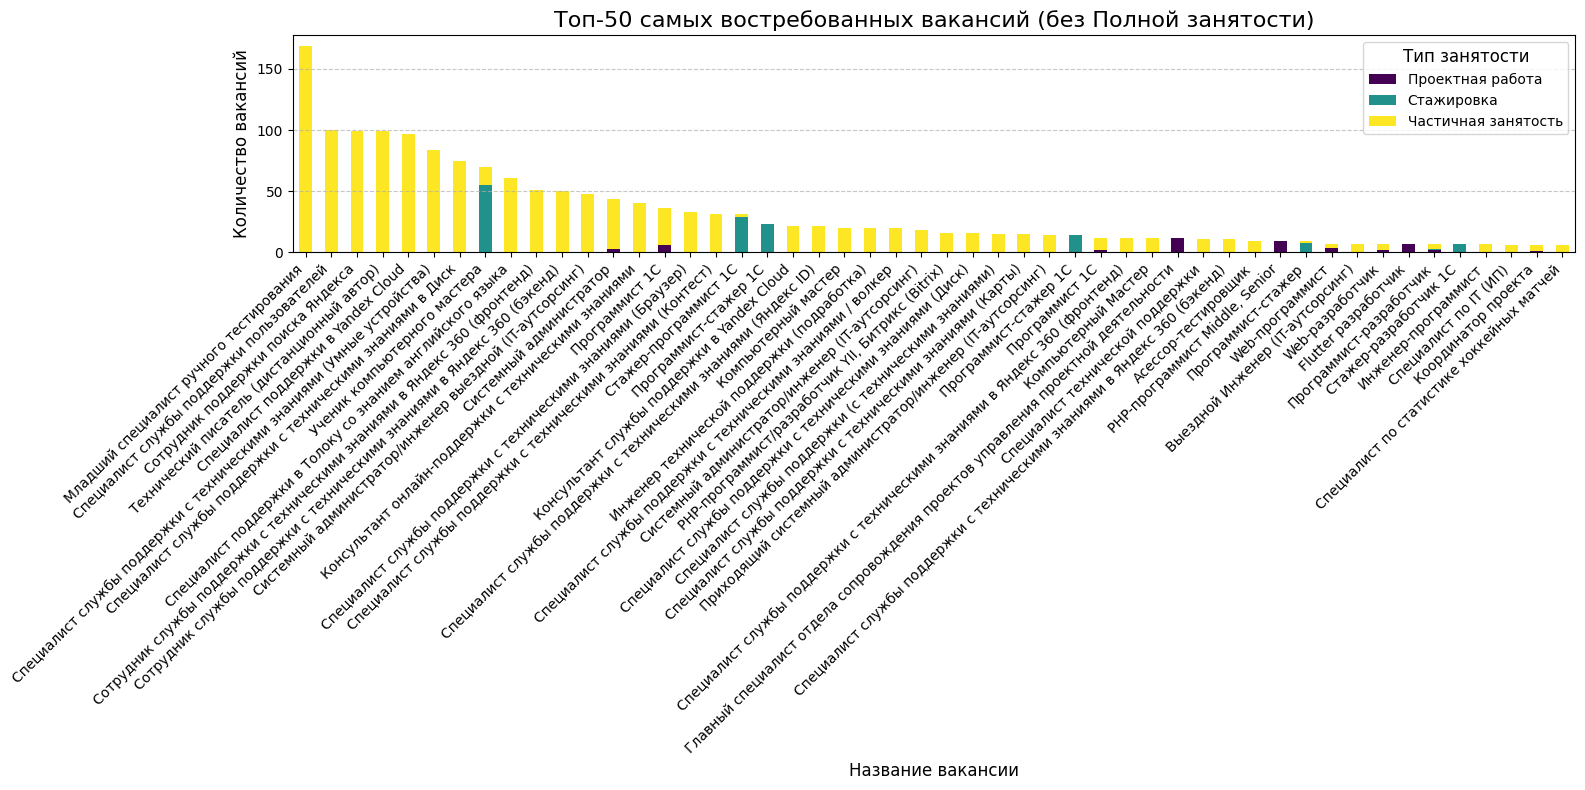

In [23]:
# Загрузка данных о типах занятости для вакансий (исключая "Полная занятость")
employment_data = pd.read_sql_query(
    '''
    SELECT name, employment, COUNT(*) AS vacancy_count
    FROM vacancies
    WHERE employment != 'Полная занятость'
    GROUP BY name, employment
    ORDER BY name, vacancy_count DESC
    ''',
    connection
)

# Преобразование данных в сводную таблицу
pivot_table = employment_data.pivot_table(
    index='name',  # Название вакансии
    columns='employment',  # Тип занятости
    values='vacancy_count',  # Количество вакансий
    fill_value=0  # Заполнение пропусков нулями
)

# Добавление столбца с общим количеством вакансий для каждой должности
pivot_table['Total'] = pivot_table.sum(axis=1)

# Сортировка по общему количеству вакансий
pivot_table = pivot_table.sort_values(by='Total', ascending=False)
pivot_table = pivot_table.drop('Total', axis=1)

# Оставляем только топ-50 вакансий
top_50_vacancies = pivot_table.head(50)

# Построение графика
plt.figure(figsize=(16, 8))
ax = top_50_vacancies.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

# Настройка внешнего вида графика
plt.title('Топ-50 самых востребованных вакансий (без Полной занятости)', fontsize=16)
plt.xlabel('Название вакансии', fontsize=12)
plt.ylabel('Количество вакансий', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Тип занятости', fontsize=10, title_fontsize=12)

# Добавление сетки
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

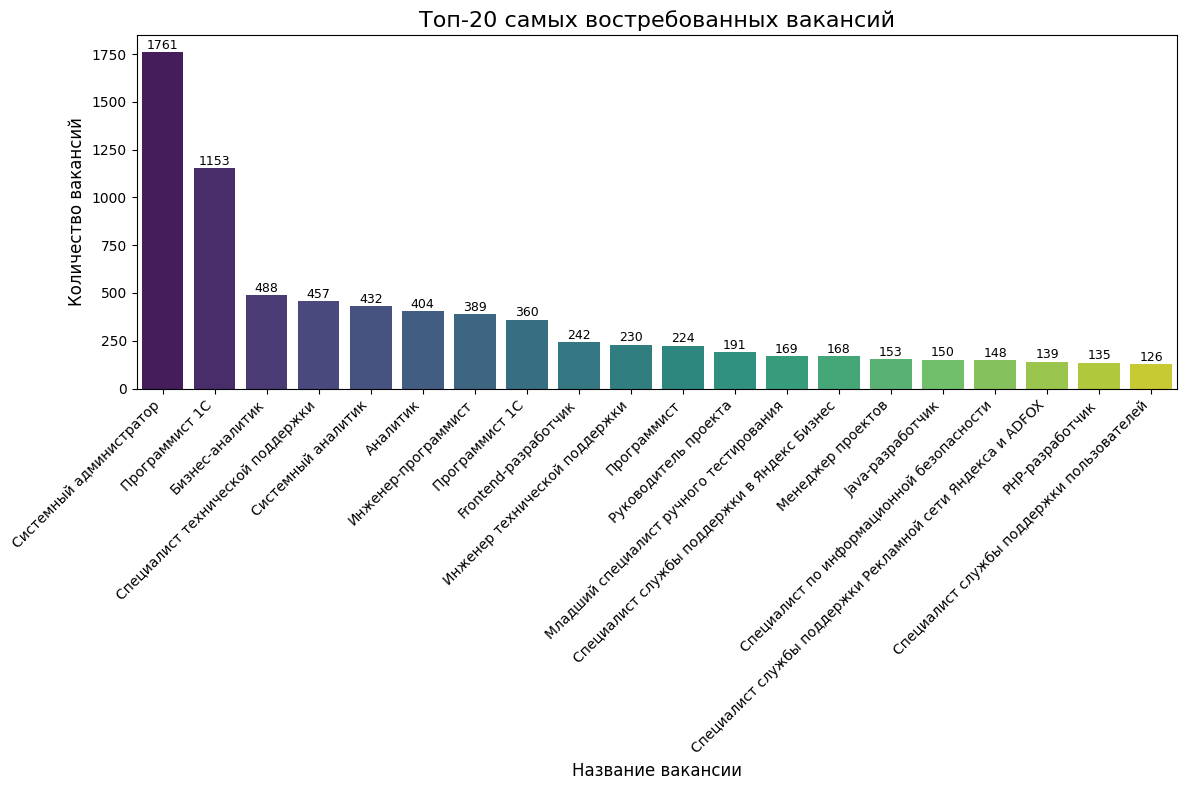

In [24]:
# Загрузка данных о топ-20 самых востребованных вакансий
top_vacancies = pd.read_sql_query(
    '''
    SELECT name, COUNT(*) AS vacancy_count
    FROM vacancies
    GROUP BY name
    ORDER BY vacancy_count DESC
    LIMIT 20
    ''',
    connection
)

# Построение графика
plt.figure(figsize=(12, 8))

bar_plot = sns.barplot(
    x='name', 
    y='vacancy_count', 
    data=top_vacancies, 
    palette='viridis'
)

# Настройка заголовков и меток осей
plt.title('Топ-20 самых востребованных вакансий', fontsize=16)
plt.xlabel('Название вакансии', fontsize=12)
plt.ylabel('Количество вакансий', fontsize=12)

# Поворот подписей по оси X
plt.xticks(rotation=45, ha='right', fontsize=10)

# Добавление числовых меток на столбцы
for patch in bar_plot.patches:
    height = patch.get_height()
    bar_plot.annotate(
        f'{int(height)}', 
        (patch.get_x() + patch.get_width() / 2., height), 
        ha='center', 
        va='center', 
        xytext=(0, 5), 
        textcoords='offset points', 
        fontsize=9
    )

plt.tight_layout()

# Отображение графика
plt.show()

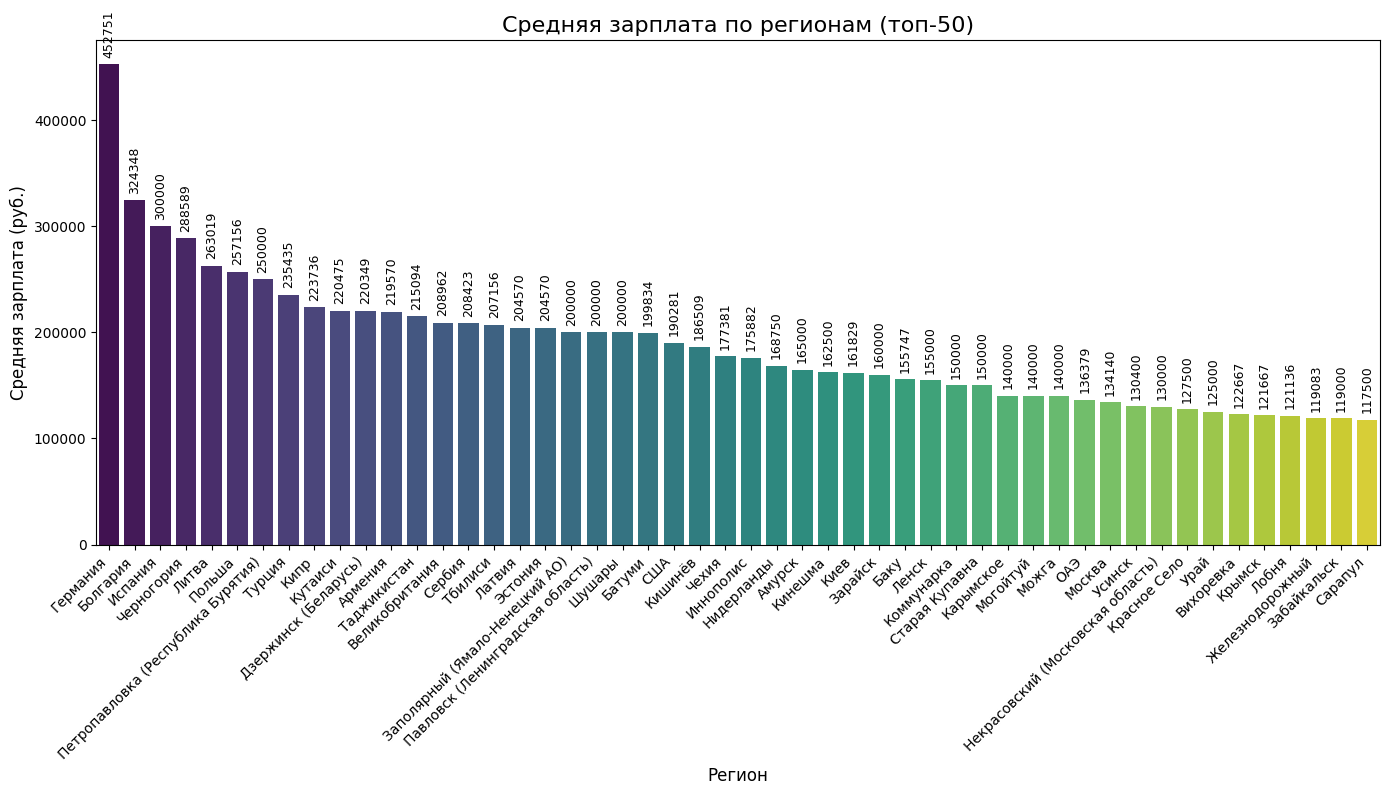

In [26]:
# Загрузка данных о средней зарплате по регионам (топ-50)
salary_by_region = pd.read_sql_query(
    '''
    SELECT
        a.name AS region,
        ROUND(AVG(COALESCE((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to)), 0) AS avg_salary
    FROM vacancies v
    JOIN areas a ON v.area_id = a.id
    WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL
    GROUP BY a.name
    ORDER BY avg_salary DESC
    LIMIT 50
    ''',
    connection
)

# Построение графика
plt.figure(figsize=(14, 8))

# Используем seaborn для создания barplot
bar_plot = sns.barplot(
    x='region', 
    y='avg_salary', 
    data=salary_by_region, 
    palette='viridis'
)

# Настройка заголовков и меток осей
plt.title('Средняя зарплата по регионам (топ-50)', fontsize=16)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Средняя зарплата (руб.)', fontsize=12)

# Поворот подписей по оси X для лучшей читаемости
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Добавление числовых меток на столбцы
for patch in bar_plot.patches:
    height = patch.get_height()
    bar_plot.annotate(
        f'{int(height)}', 
        (patch.get_x() + patch.get_width() / 2., height), 
        ha='center', 
        va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points', 
        fontsize=9, 
        rotation=90
    )

# Улучшение компоновки графика
plt.tight_layout()

# Отображение графика
plt.show()

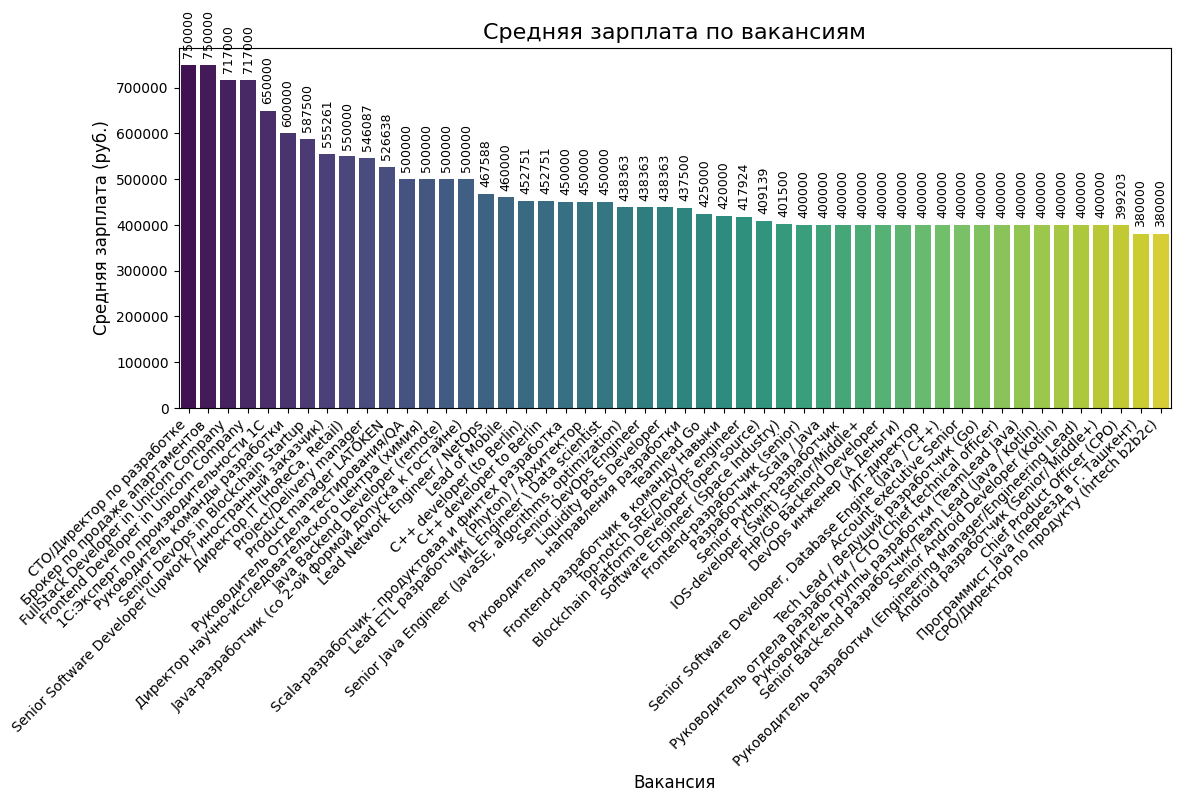

In [28]:
# Загрузка данных о средней зарплате по вакансиям
salary_by_region = pd.read_sql_query(
    '''
    SELECT 
        name AS region, 
        ROUND(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)), 0) AS avg_salary
    FROM vacancies v
    WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL
    GROUP BY name
    ORDER BY avg_salary DESC
    LIMIT 50
    ''',
    connection
)

# Построение графика
plt.figure(figsize=(12, 8))

# Используем seaborn для создания barplot
bar_plot = sns.barplot(
    x='region', 
    y='avg_salary', 
    data=salary_by_region, 
    palette='viridis'
)

# Настройка заголовков и меток осей
plt.title('Средняя зарплата по вакансиям', fontsize=16)
plt.xlabel('Вакансия', fontsize=12)
plt.ylabel('Средняя зарплата (руб.)', fontsize=12)

# Поворот подписей по оси X для лучшей читаемости
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Добавление числовых меток на столбцы
for patch in bar_plot.patches:
    height = patch.get_height()
    bar_plot.annotate(
        f'{int(height)}',  # Приводим к целому числу
        (patch.get_x() + patch.get_width() / 2., height), 
        ha='center', 
        va='bottom', 
        xytext=(0, 5), 
        textcoords='offset points', 
        fontsize=9, 
        rotation=90
    )

# Улучшение компоновки графика
plt.tight_layout()

# Отображение графика
plt.show()

In [29]:
connection.close()